# Prueba

Frecuencia de muestreo: 11025 Hz. Frecuencia de Nyquist: 5512.5 Hz.

In [2]:
import thinkdsp
import matplotlib.pyplot as plt
#import thinkplot

## 1. Señal cuadrada

Cargamos el audio y observamos su espectro.

In [ ]:
wave = thinkdsp.read_wave('untitled/cuadrada.wav')
#wave = thinkdsp.read_wave('Solemne1/mystery.wav')
wave.normalize()
wave.make_audio()

spectrum = wave.make_spectrum()
spectrum.plot()

FileNotFoundError: [Errno 2] No such file or directory: 'untitled/cuadrada.wav'

El primer pico está en **2100 Hz**, por lo que esa es la frecuencia fundamental. Los demás picos corresponden a armónicos impares plegados por aliasing: por ejemplo, el tercer armónico (6300 Hz) aparece en 4725 Hz.

Se compara con una onda cuadrada de 2100 Hz y luego se conserva sólo la banda de la fundamental. No se puede recuperar la onda cuadrada original completa, porque sus armónicos ya fueron afectados por aliasing.

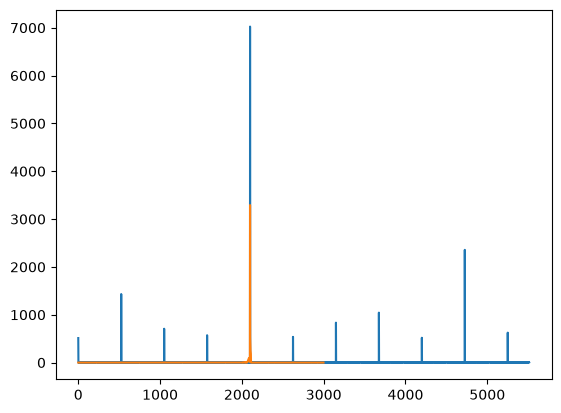

In [9]:
thinkdsp.SquareSignal(2100).make_wave().make_spectrum().plot()

spectrum.high_pass(2000)
spectrum.low_pass(2110)
spectrum.plot(high=3000)
spectrum.make_wave().make_audio()

## 2. Señal desconocida

Se carga la señal y se usa un espectrograma para ver cómo cambian las frecuencias en el tiempo.

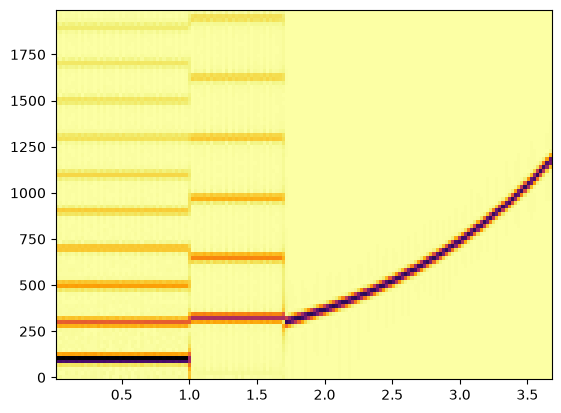

In [10]:
wave = thinkdsp.read_wave('untitled/desconocida.wav')
wave.normalize()
wave.make_audio()

spectrogram = wave.make_spectrogram(512)
spectrogram.plot(high=2000)

La señal cambia con el tiempo. Entre 0 y 1 s es una **onda cuadrada de 100 Hz**; entre 1 y 1.7 s es una **onda diente de sierra de 300 Hz**. Desde 1.7 hasta 3.7 s aparece un **ExpoChirp cosenoidal**, que aumenta aproximadamente de 300 a 1200 Hz.

Las líneas horizontales corresponden a frecuencias constantes; la curva ascendente final muestra que la frecuencia aumenta de forma exponencial.

## 3. Señal enmascarada

En el tiempo domina el ruido, por lo que analizamos el espectro.

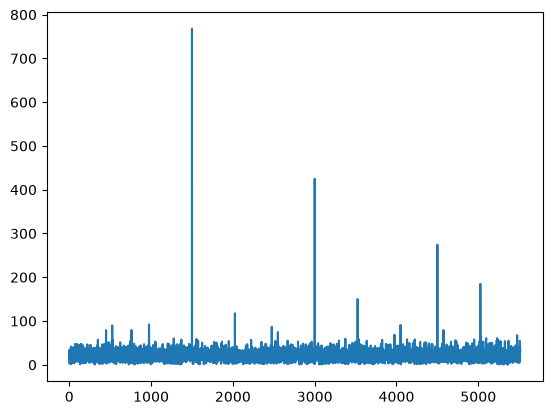

In [11]:
wave = thinkdsp.read_wave('untitled/incognita.wav')
wave.normalize()
wave.make_audio()

spectrum = wave.make_spectrum()
spectrum.plot()

Sí, hay una señal bajo el ruido. El espectro presenta picos cerca de **1500, 3000 y 4500 Hz**: fundamental y armónicos consecutivos. Por ello, la señal enmascarada es una **onda diente de sierra de 1500 Hz**.

No es cosenoidal porque tiene varios armónicos, ni triangular porque aparecen armónicos pares e impares.